In [ ]:
!pip install transformers -q

In [ ]:
!pip install comet_ml

In [ ]:
from comet_ml import Experiment

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision
import torchvision.transforms as transforms
from torchvision import models
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

In [ ]:
def seed_everything(seed):
  random.seed(seed)
  os.environ['PYTHONHASHSEED'] = str(seed)
  np.random.seed(seed)
  torch.manual_seed(seed)
  torch.cuda.manual_seed(seed)
  torch.backends.cudnn.deterministic = True
  torch.backends.cudnn.benchmark = False

class CFG:
  num_epochs = 5
  batch_size = 32
  num_workers = 2
  lr = 1e-4
  seed = 42
seed_everything(CFG.seed)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from pathlib import Path

df = pd.read_excel('/content/drive/MyDrive/GP5_final/oskelly_dataset.xlsx')
df = df.dropna(subset=['image_path']).reset_index(drop=True)
df['image_path'] = df['image_path'].str.split('\\').str[-1]
df['image_path'] = '/content/drive/MyDrive/GP5_final/oskelly_images/' + df['image_path']

In [ ]:
# from pathlib import Path
# path = '/content/drive/MyDrive/GP5'
# parts = sorted(Path(path).glob('all_items_*_with_images.xlsx'))
# df = pd.concat([pd.read_excel(p) for p in parts], ignore_index=True)
# df['image_path'] = df['image_path'].str.replace('/content/udrive/', '/content/drive/', regex=False)

In [ ]:
sl = {
    'Вечерние платья': 'Платья',
    'Другие платья': 'Платья',
    'Коктейльные платья': 'Платья',
    'Повседневные платья': 'Платья',
    'Сарафаны': 'Платья',
    'Юбки макси': 'Юбки',
    'Юбки миди': 'Юбки',
    'Юбки мини': 'Юбки',
    'Юбки-шорты': 'Юбки',
    'Брюки узкие': 'Брюки',
    'Брюки широкие': 'Брюки',
    'Прямые брюки': 'Брюки',
    'Кюлоты': 'Брюки',
    'Бриджи': 'Брюки',
    'Леггинсы и велосипедки': 'Брюки',
    'Зауженные джинсы': 'Джинсы',
    'Прямые джинсы': 'Джинсы',
    'Расклешенные джинсы': 'Джинсы',
    'Шорты': 'Шорты',
    'Блузы': 'Блузы и рубашки',
    'Рубашки': 'Блузы и рубашки',
    'Водолазки': 'Топы с длинным рукавом',
    'Лонгсливы': 'Топы с длинным рукавом',
    'Майки': 'Майки и футболки',
    'Футболки': 'Майки и футболки',
    'Туники': 'Майки и футболки',
    'Джемперы и свитеры': 'Трикотаж',
    'Кардиганы': 'Трикотаж',
    'Худи и толстовки': 'Худи и толстовки',
    'Пальто': 'Верхняя одежда',
    'Куртки': 'Верхняя одежда',
    'Пуховики': 'Верхняя одежда',
    'Парки': 'Верхняя одежда',
    'Тренчи и плащи': 'Верхняя одежда',
    'Дубленки': 'Верхняя одежда',
    'Шубы': 'Верхняя одежда',
    'Жакеты и пиджаки': 'Жакеты и пиджаки',
    'Накидки и пончо': 'Верхняя одежда',
    'Жилетки': 'Жилеты',
    'Жилеты': 'Жилеты',
    'Костюмы с брюками': 'Костюмы и комплекты',
    'Костюмы с юбками': 'Костюмы и комплекты',
    'Комплекты': 'Костюмы и комплекты',
    'Комбинезоны': 'Комбинезоны',
    'Бюстгалтеры': 'Белье',
    'Корсеты': 'Белье',
    'Боди': 'Боди',
    'Носки, чулки и колготы': 'Носки, чулки и колготы',
    'Купальники': 'Купальники и пляж',
    'Парео': 'Купальники и пляж',
    'Спортивные брюки и шорты': 'Спортивная одежда',
    'Спортивные костюмы': 'Спортивная одежда',
    'Спортивные куртки': 'Спортивная одежда',
    'Пижамы': 'Пижамы',
    'Пижамы и сорочки': 'Пижамы',
}

In [ ]:
df['Категория для label'] = df['Категория'].map(sl)

In [ ]:
sub = df.groupby(by=['Категория для label'])['image_path'].count().reset_index().sort_values(by=['image_path'])
top_labels = sub[sub['image_path'] > len(df)//100]['Категория для label'].values
top_labels

array(['Жилеты', 'Жакеты и пиджаки', 'Топы с длинным рукавом', 'Юбки',
       'Брюки', 'Шорты', 'Блузы и рубашки', 'Джинсы', 'Трикотаж',
       'Худи и толстовки', 'Платья', 'Верхняя одежда', 'Майки и футболки'],
      dtype=object)

In [ ]:
df = df[df['Категория для label'].isin(top_labels)]
df = df.dropna(subset=['Категория для label']).reset_index(drop=True)
df.shape

(7717, 24)

In [ ]:
from sklearn.model_selection import train_test_split

labels = sorted(df['Категория для label'].unique())
label2idx = {l: i for i, l in enumerate(labels)}
df['label'] = df['Категория для label'].map(label2idx)

In [ ]:
train_df, val_df = train_test_split(
  df, test_size=0.2, stratify=df['label'], random_state=CFG.seed
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
print(len(train_df), len(val_df))

6173 1544


In [ ]:
class OskellyDataset(Dataset):
  def __init__(self, df, transform=None):
    self.df = df
    self.transform = transform

  def __len__(self):
    return len(self.df)

  def __getitem__(self, idx):
    row = self.df.iloc[idx]
    image = Image.open(row['image_path']).convert('RGB')
    label = row['label']
    if self.transform:
      image = self.transform(image)
    return image, label

In [ ]:
IMAGE_SIZE = 300

train_transform = transforms.Compose([
  transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
  transforms.RandomHorizontalFlip(),
  transforms.RandomRotation(15),
  transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
  transforms.ToTensor(),
  transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
val_transform = transforms.Compose([
  transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
  transforms.ToTensor(),
  transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [ ]:
train_dataset = OskellyDataset(train_df, transform=train_transform)
val_dataset = OskellyDataset(val_df, transform=val_transform)
train_loader = DataLoader(
  train_dataset,
  batch_size=CFG.batch_size,
  shuffle=True,
  num_workers=CFG.num_workers,
  pin_memory=True,
)
val_loader = DataLoader(
  val_dataset,
  batch_size=CFG.batch_size,
  shuffle=False,
  num_workers=CFG.num_workers,
  pin_memory=True,
)

len(train_loader), len(val_loader)

(193, 49)

In [ ]:
from torchvision.models import efficientnet_b3, EfficientNet_B3_Weights
model = efficientnet_b3(weights=EfficientNet_B3_Weights.DEFAULT)

for param in model.parameters():
  param.requires_grad = False

in_features = model.classifier[1].in_features
in_features

1536

In [ ]:
model.classifier = nn.Sequential(
  nn.Dropout(p=0.3),
  nn.Linear(in_features, 13),
)
model = model.to(device)

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

def train(model, train_loader, val_loader, num_epochs, lr, experiment=None):
  optimizer = torch.optim.Adam(model.parameters(), lr=lr)
  criterion = nn.CrossEntropyLoss()

  if experiment:
    experiment.log_parameters({
      'epochs': num_epochs,
      'lr': lr,
      'batch_size': CFG.batch_size,
      'model': 'EfficientNet-B3',
    })
  best_f1 = 0

  for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    for images, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}'):
      images, labels = images.to(device), labels.to(device)
      optimizer.zero_grad()
      logits = model(images)
      loss = criterion(logits, labels)
      loss.backward()
      optimizer.step()
      train_loss += loss.item()
    train_loss /= len(train_loader)

    model.eval()
    val_loss = 0
    all_preds = []
    all_true = []

    with torch.no_grad():
      for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        val_loss += criterion(logits, labels).item()
        all_preds += logits.argmax(dim=1).tolist()
        all_true += labels.tolist()

    val_loss /= len(val_loader)
    val_acc = accuracy_score(all_true, all_preds)
    val_f1 = f1_score(all_true, all_preds, average='macro')

    print(f'Epoch {epoch+1}: train_loss={train_loss:.4f} val_loss={val_loss:.4f} val_acc={val_acc:.4f} val_f1={val_f1:.4f}')
    if experiment:
      experiment.log_metrics({
        'train_loss': train_loss,
        'val_loss': val_loss,
        'val_acc': val_acc,
        'val_macro_f1': val_f1,
      }, step=epoch)

    if val_f1 > best_f1:
      best_f1 = val_f1
      torch.save(model.state_dict(), 'best_model.pth')
      print(f'Сохранили модель, f1={best_f1:.4f}')
  return model

In [ ]:
experiment = Experiment(
  api_key='XXXXXXXXXXXXXXXXXX',
  project_name='oskelly-cv',
  workspace='gp5_team1',
)
experiment.set_name('EfficientNetB3 stage1')
experiment.add_tags(['efficientnet-b3', 'stage1', 'lr1e-3'])

COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : EfficientNetB3 stage1
COMET INFO:     url                   : https://www.comet.com/gp5-team1/oskelly-cv/d1448698cd554b9eb9413c79666d1253
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     loss [20] : (1.1406033039093018, 2.6246378421783447)
COMET INFO:   Others:
COMET INFO:     Name         : EfficientNetB3 stage1
COMET INFO:     notebook_url : https://colab.research.google.com/notebook#fileId=1VeJz92zPhv3HAp_5M8u12j7lCIGWIzns
COMET INFO:   Parameters:
COMET INFO:     batch_size : 32
COMET INFO:     epochs     : 5
COMET INFO:     lr         : 0.001
COMET INFO:     model      : EfficientNet-B3
COMET INFO:   Uploads:
COMET INFO:     environment

In [ ]:
model = train(model, train_loader, val_loader, num_epochs=5, lr=1e-3, experiment=experiment)

Epoch 1/5:   0%|          | 0/193 [00:00<?, ?it/s]

Epoch 1: train_loss=1.6441 val_loss=1.1364 val_acc=0.6775 val_f1=0.5399
Сохранили модель, f1=0.5399


Epoch 2/5:   0%|          | 0/193 [00:00<?, ?it/s]

Epoch 2: train_loss=1.1785 val_loss=0.9247 val_acc=0.7176 val_f1=0.6104
Сохранили модель, f1=0.6104


Epoch 3/5:   0%|          | 0/193 [00:00<?, ?it/s]

Epoch 3: train_loss=1.0675 val_loss=0.8351 val_acc=0.7358 val_f1=0.6464
Сохранили модель, f1=0.6464


Epoch 4/5:   0%|          | 0/193 [00:00<?, ?it/s]

Epoch 4: train_loss=0.9972 val_loss=0.8138 val_acc=0.7429 val_f1=0.6562
Сохранили модель, f1=0.6562


Epoch 5/5:   0%|          | 0/193 [00:00<?, ?it/s]

Epoch 5: train_loss=0.9523 val_loss=1.4292 val_acc=0.7494 val_f1=0.6676
Сохранили модель, f1=0.6676


In [ ]:
model = train(model, train_loader, val_loader, num_epochs=5, lr=1e-3, experiment=experiment)

Epoch 1/5:   0%|          | 0/193 [00:00<?, ?it/s]

Epoch 1: train_loss=0.9244 val_loss=0.7914 val_acc=0.7610 val_f1=0.6826
Сохранили модель, f1=0.6826


Epoch 2/5:   0%|          | 0/193 [00:00<?, ?it/s]

Epoch 2: train_loss=0.8988 val_loss=1.5322 val_acc=0.7558 val_f1=0.6812


Epoch 3/5:   0%|          | 0/193 [00:00<?, ?it/s]

Epoch 3: train_loss=0.8875 val_loss=0.9245 val_acc=0.7681 val_f1=0.6961
Сохранили модель, f1=0.6961


Epoch 4/5:   0%|          | 0/193 [00:00<?, ?it/s]

Epoch 4: train_loss=0.8650 val_loss=0.7125 val_acc=0.7649 val_f1=0.6907


Epoch 5/5:   0%|          | 0/193 [00:00<?, ?it/s]

Epoch 5: train_loss=0.8553 val_loss=0.8727 val_acc=0.7701 val_f1=0.7024
Сохранили модель, f1=0.7024


In [ ]:
experiment.end()

COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : EfficientNetB3 stage1
COMET INFO:     url                   : https://www.comet.com/gp5-team1/oskelly-cv/3202da114b8741d797e2ae4efc07294e
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     loss [191]        : (0.5958254933357239, 2.6246378421783447)
COMET INFO:     train_loss [10]   : (0.8553152658778769, 1.6440541305690233)
COMET INFO:     val_acc [10]      : (0.677461139896373, 0.7700777202072538)
COMET INFO:     val_loss [10]     : (0.7125223577022552, 1.5321586046900069)
COMET INFO:     val_macro_f1 [10] : (0.5398840143178008, 0.7024076559126564)
COMET INFO:   Others:
COMET INFO:     Name         : EfficientNetB3 stage1
COMET INFO:     not

In [ ]:
model.load_state_dict(torch.load('best_model.pth'))

<All keys matched successfully>

In [ ]:
for name, param in model.named_parameters():
  if 'features.7' in name or 'features.8' in name or 'classifier' in name:
    param.requires_grad = True

In [ ]:
experiment = Experiment(
  api_key='XXXXXXXXXXXXXXXXX',
  project_name='oskelly-cv',
  workspace='gp5_team1',
)
experiment.set_name('EfficientNetB3 stage2')
experiment.add_tags(['efficientnet-b3', 'stage2', 'unfreeze-7-8', 'lr1e-4'])

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/gp5-team1/oskelly-cv/20f157c0e6be4bac8398a89d8489f9fe

COMET INFO: Couldn't find a Git repository in '/content' nor in any parent directory. Set `COMET_GIT_DIRECTORY` if your Git Repository is elsewhere.


In [ ]:
model = train(model, train_loader, val_loader, num_epochs=5, lr=1e-4, experiment=experiment)

Epoch 1/5:   0%|          | 0/193 [00:00<?, ?it/s]

Epoch 1: train_loss=0.7773 val_loss=0.6649 val_acc=0.7940 val_f1=0.7401
Сохранили модель, f1=0.7401


Epoch 2/5:   0%|          | 0/193 [00:00<?, ?it/s]

Epoch 2: train_loss=0.6869 val_loss=1.1544 val_acc=0.7623 val_f1=0.7003


Epoch 3/5:   0%|          | 0/193 [00:00<?, ?it/s]

Epoch 3: train_loss=0.6153 val_loss=0.5801 val_acc=0.8005 val_f1=0.7427
Сохранили модель, f1=0.7427


Epoch 4/5:   0%|          | 0/193 [00:00<?, ?it/s]

Epoch 4: train_loss=0.5630 val_loss=1.3052 val_acc=0.8167 val_f1=0.7672
Сохранили модель, f1=0.7672


Epoch 5/5:   0%|          | 0/193 [00:00<?, ?it/s]

Epoch 5: train_loss=0.5272 val_loss=1.3126 val_acc=0.8128 val_f1=0.7639


In [ ]:
experiment.end()

COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : EfficientNetB3 stage2
COMET INFO:     url                   : https://www.comet.com/gp5-team1/oskelly-cv/20f157c0e6be4bac8398a89d8489f9fe
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     loss [96]        : (0.2758222818374634, 1.2442803382873535)
COMET INFO:     train_loss [5]   : (0.5272486134977539, 0.7772866313012771)
COMET INFO:     val_acc [5]      : (0.7623056994818653, 0.8167098445595855)
COMET INFO:     val_loss [5]     : (0.5801160633563995, 1.3126231520151606)
COMET INFO:     val_macro_f1 [5] : (0.700256389285602, 0.7672415239350543)
COMET INFO:   Others:
COMET INFO:     Name         : EfficientNetB3 stage2
COMET INFO:     notebook

In [ ]:
model.load_state_dict(torch.load('best_model.pth'))

<All keys matched successfully>

In [ ]:
for name, param in model.named_parameters():
  if 'features.5' in name or 'features.6' in name or 'features.7' in name or 'features.8' in name or 'classifier' in name:
    param.requires_grad = True

In [ ]:
experiment = Experiment(
  api_key='XXXXXXXXXXXXXXXX',
  project_name='oskelly-cv',
  workspace='gp5_team1',
)
experiment.set_name('EfficientNetB3 stage3')
experiment.add_tags(['efficientnet-b3', 'stage3', 'unfreeze-5-8', 'lr1e-5'])

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Couldn't find a Git repository in '/content' nor in any parent directory. Set `COMET_GIT_DIRECTORY` if your Git Repository is elsewhere.
COMET INFO: Experiment is live on comet.com https://www.comet.com/gp5-team1/oskelly-cv/3330f2fb5e9f499886b6e0e60d31ed45



In [ ]:
model = train(model, train_loader, val_loader, num_epochs=5, lr=1e-5, experiment=experiment)

Epoch 1/5:   0%|          | 0/193 [00:00<?, ?it/s]

Epoch 1: train_loss=0.5028 val_loss=0.5556 val_acc=0.8141 val_f1=0.7623
Сохранили модель, f1=0.7623


Epoch 2/5:   0%|          | 0/193 [00:00<?, ?it/s]

Epoch 2: train_loss=0.4630 val_loss=0.5608 val_acc=0.8083 val_f1=0.7496


Epoch 3/5:   0%|          | 0/193 [00:00<?, ?it/s]

Epoch 3: train_loss=0.4468 val_loss=0.5645 val_acc=0.8161 val_f1=0.7607


Epoch 4/5:   0%|          | 0/193 [00:00<?, ?it/s]

Epoch 4: train_loss=0.4367 val_loss=0.5440 val_acc=0.8199 val_f1=0.7679
Сохранили модель, f1=0.7679


Epoch 5/5:   0%|          | 0/193 [00:00<?, ?it/s]

Epoch 5: train_loss=0.4097 val_loss=0.9689 val_acc=0.8180 val_f1=0.7632


In [ ]:
experiment.end()

COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : EfficientNetB3 stage3
COMET INFO:     url                   : https://www.comet.com/gp5-team1/oskelly-cv/3330f2fb5e9f499886b6e0e60d31ed45
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     loss [96]        : (0.15868425369262695, 0.8688303232192993)
COMET INFO:     train_loss [5]   : (0.40971110861536136, 0.5027894085861858)
COMET INFO:     val_acc [5]      : (0.8082901554404145, 0.8199481865284974)
COMET INFO:     val_loss [5]     : (0.5439897039715125, 0.9689160664470828)
COMET INFO:     val_macro_f1 [5] : (0.7495810454763473, 0.7679499495159672)
COMET INFO:   Others:
COMET INFO:     Name         : EfficientNetB3 stage3
COMET INFO:     noteb

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

model.load_state_dict(torch.load('best_model.pth'))
model.eval()
all_preds = []
all_true = []

with torch.no_grad():
  for images, labels in val_loader:
    images, labels = images.to(device), labels.to(device)
    logits = model(images)
    all_preds += logits.argmax(dim=1).tolist()
    all_true += labels.tolist()

print(classification_report(all_true, all_preds, target_names=list(label2idx.keys())))

                        precision    recall  f1-score   support

       Блузы и рубашки       0.73      0.60      0.66        80
                 Брюки       0.88      0.92      0.90        73
        Верхняя одежда       0.68      0.91      0.78       206
                Джинсы       0.94      0.90      0.92        98
      Жакеты и пиджаки       0.70      0.53      0.60        40
                Жилеты       0.68      0.54      0.60        24
      Майки и футболки       0.91      0.93      0.92       369
                Платья       0.88      0.77      0.82       164
Топы с длинным рукавом       0.56      0.43      0.49        42
              Трикотаж       0.74      0.74      0.74       152
      Худи и толстовки       0.87      0.76      0.81       160
                 Шорты       0.86      0.95      0.90        76
                  Юбки       0.91      0.80      0.85        60

              accuracy                           0.82      1544
             macro avg       0.79     

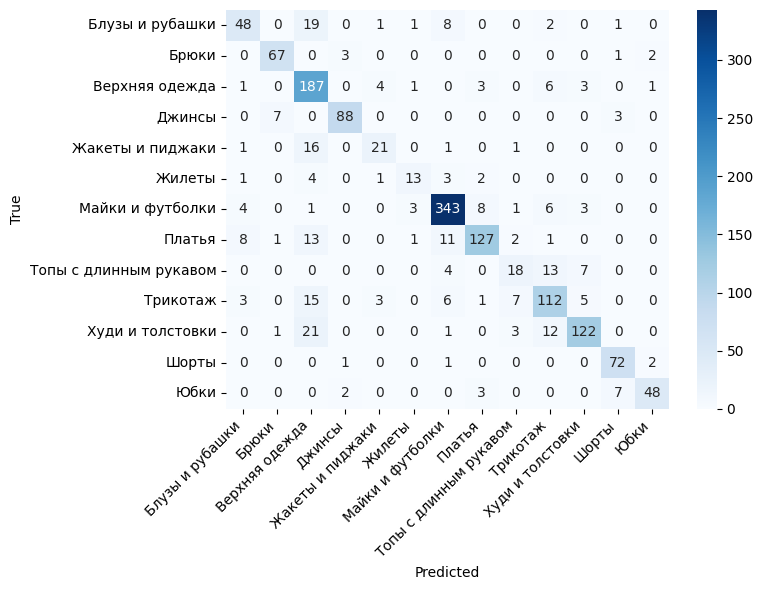

In [ ]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(all_true, all_preds)
sns.heatmap(
  cm,
  annot=True,
  fmt='d',
  xticklabels=list(label2idx.keys()),
  yticklabels=list(label2idx.keys()),
  cmap='Blues',
)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()